# Car Purchase Amount Prediction with ANN

**Author:** Tegar Reski Pratama · Informatika, Universitas Muhammadiyah Malang

Educational regression project adapted from **CODELAB Modul 1 — Artificial Neural Networks**. The model estimates `car purchase amount` from four numeric features.

**Output provenance:** Training outputs and the chart below are retained from the supplied codelab notebook. The portfolio preparation did not rerun training because the CSV was not supplied. Execution counters in the source notebook are unset; the saved outputs are not an independently verified run.

**Dataset:** Place `MODULE 1_CODELAB.csv` beside this notebook before running the cells in order. See `DATASET.md` for the schema. Customer identities are excluded from the displayed preview.


## 1. Import Necessary Libraries



In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

tf.keras.utils.set_random_seed(0)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## 2. Load Dataset

Gunakan CSV yang disediakan pada modul. File aslinya memerlukan encoding `cp1252`.

In [ ]:
csv_path = Path("MODULE 1_CODELAB.csv")
if not csv_path.exists():
    try:
        from google.colab import files
        print("Unggah MODULE 1_CODELAB.csv")
        files.upload()
    except ImportError as exc:
        raise FileNotFoundError(
            "Letakkan MODULE 1_CODELAB.csv di folder yang sama dengan notebook."
        ) from exc

df = pd.read_csv(csv_path, encoding="cp1252")
print("Ukuran dataset:", df.shape)
display(df[["age", "annual Salary", "credit card debt", "net worth", "car purchase amount"]].head(10))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [ ]:
display(df.select_dtypes(include="number").describe())
print("Nilai kosong per kolom:")
display(df.isna().sum().to_frame("jumlah_kosong"))

## 3. Data Preprocessing

Hapus identitas dan atribut kategorikal yang tidak dipakai pada rancangan empat fitur modul. Periksa tidak ada nilai kosong pada fitur dan target.

In [ ]:
df_model = df.drop(
    columns=["customer name", "customer e-mail", "country", "gender"]
).copy()
X = df_model.drop(columns="car purchase amount")
y = df_model["car purchase amount"]

assert X.shape[1] == 4, "Model modul mensyaratkan empat fitur."
assert not X.isna().any().any() and not y.isna().any(), "Tangani nilai kosong terlebih dahulu."
print("Fitur:", X.columns.tolist())
print("Bentuk X:", X.shape, "| Bentuk y:", y.shape)
display(df_model.head())

Fitur: ['age', 'annual Salary', 'credit card debt', 'net worth']
Bentuk X: (500, 4) | Bentuk y: (500,)


,age,annual Salary,credit card debt,net worth,car purchase amount
0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


## 4. Data Standardization

Modul memakai `MinMaxScaler` untuk X dan y. Scaler dibuat sekarang dan **di-fit hanya pada data latih** setelah split pada langkah 5, untuk menghindari kebocoran informasi data uji.

In [ ]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
print("Dua MinMaxScaler disiapkan untuk fitur dan target.")

Dua MinMaxScaler disiapkan untuk fitur dan target.


## 5. Data Splitting

Gunakan `test_size=0.2` dan `random_state=0`; kemudian fit scaler pada train dan transform test.

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, random_state=0
)
print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Test :", X_test_raw.shape, y_test_raw.shape)

Train: (400, 4) (400,)
Test : (100, 4) (100,)


In [ ]:
X_train = x_scaler.fit_transform(X_train_raw).astype("float32")
X_test = x_scaler.transform(X_test_raw).astype("float32")
y_train = y_scaler.fit_transform(y_train_raw.to_numpy().reshape(-1, 1)).astype("float32")
y_test = y_scaler.transform(y_test_raw.to_numpy().reshape(-1, 1)).astype("float32")

print("Rentang X_train:", round(float(X_train.min()), 4), "sampai", round(float(X_train.max()), 4))
print("Rentang y_train:", round(float(y_train.min()), 4), "sampai", round(float(y_train.max()), 4))

Rentang X_train: 0.0 sampai 1.0
Rentang y_train: 0.0 sampai 1.0


## 6. Build Model

Sequential dengan tiga Dense (10 ReLU, 10 ReLU, 1 linear), optimizer Adam dan loss `mean_squared_error`. Metrik `within_10pct` berarti prediksi berada dalam ±10% dari nilai pembelian sebenarnya.
Ini adalah regresi: `within_10pct` adalah proporsi dalam toleransi, bukan akurasi klasifikasi.


In [ ]:
target_range = tf.constant(float(y_scaler.data_range_[0]), dtype=tf.float32)
target_min = tf.constant(float(y_scaler.data_min_[0]), dtype=tf.float32)

def within_10pct(y_true, y_pred):
    actual = y_true * target_range + target_min
    absolute_error = tf.abs(y_pred - y_true) * target_range
    correct = absolute_error <= 0.10 * tf.maximum(tf.abs(actual), 1.0)
    return tf.reduce_mean(tf.cast(correct, tf.float32))

model = Sequential([
    tf.keras.Input(shape=(4,)),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(1, activation="linear"),
])
model.compile(optimizer="adam", loss="mean_squared_error", metrics=[within_10pct])
model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 171 (684.00 B)
 Trainable params: 171 (684.00 B)
 Non-trainable params: 0 (0.00 B)


## 7. Training Model

Latih selama 100 epoch dengan 20% dari data latih sebagai validasi. Data uji tidak dipakai selama pelatihan.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.20,
    verbose=0,
)
print("Epoch yang dijalankan:", len(history.history["loss"]))
print("Loss train akhir:", round(history.history["loss"][-1], 6))
print("Loss validasi akhir:", round(history.history["val_loss"][-1], 6))

Epoch yang dijalankan: 100
Loss train akhir: 3.7e-05
Loss validasi akhir: 0.000158


## 8. Model Evaluation

Ukur MSE pada skala normalisasi dan metrik regresi pada satuan asli (`car purchase amount`).

In [ ]:
test_loss, test_within_10pct = model.evaluate(X_test, y_test, verbose=0)
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_original = y_scaler.inverse_transform(y_pred_scaled).ravel()
y_true_original = y_test_raw.to_numpy()

test_mse_original = mean_squared_error(y_true_original, y_pred_original)
test_mae_original = mean_absolute_error(y_true_original, y_pred_original)
test_rmse_original = np.sqrt(test_mse_original)
test_r2 = r2_score(y_true_original, y_pred_original)
test_within_10pct_exact = np.mean(
    np.abs(y_pred_original - y_true_original)
    <= 0.10 * np.maximum(np.abs(y_true_original), 1.0)
)

print(f"Test Loss (MSE, target ternormalisasi): {test_loss:.6f}")
print(f"Test within ±10% (proporsi dalam toleransi): {test_within_10pct_exact:.2%}")
print(f"Test MAE (satuan asli): {test_mae_original:,.2f}")
print(f"Test RMSE (satuan asli): {test_rmse_original:,.2f}")
print(f"Test R²: {test_r2:.4f}")

Test Loss (MSE, target ternormalisasi): 0.000042
Test within ±10% (proporsi dalam toleransi): 99.00%
Test MAE (satuan asli): 316.87
Test RMSE (satuan asli): 458.09
Test R²: 0.9983


## 9. Plotting Accuracy and Loss

Panel kiri menunjukkan proporsi prediksi dalam ±10% nilai sebenarnya, dan panel kanan menunjukkan MSE. Keduanya ditampilkan untuk train serta validasi.

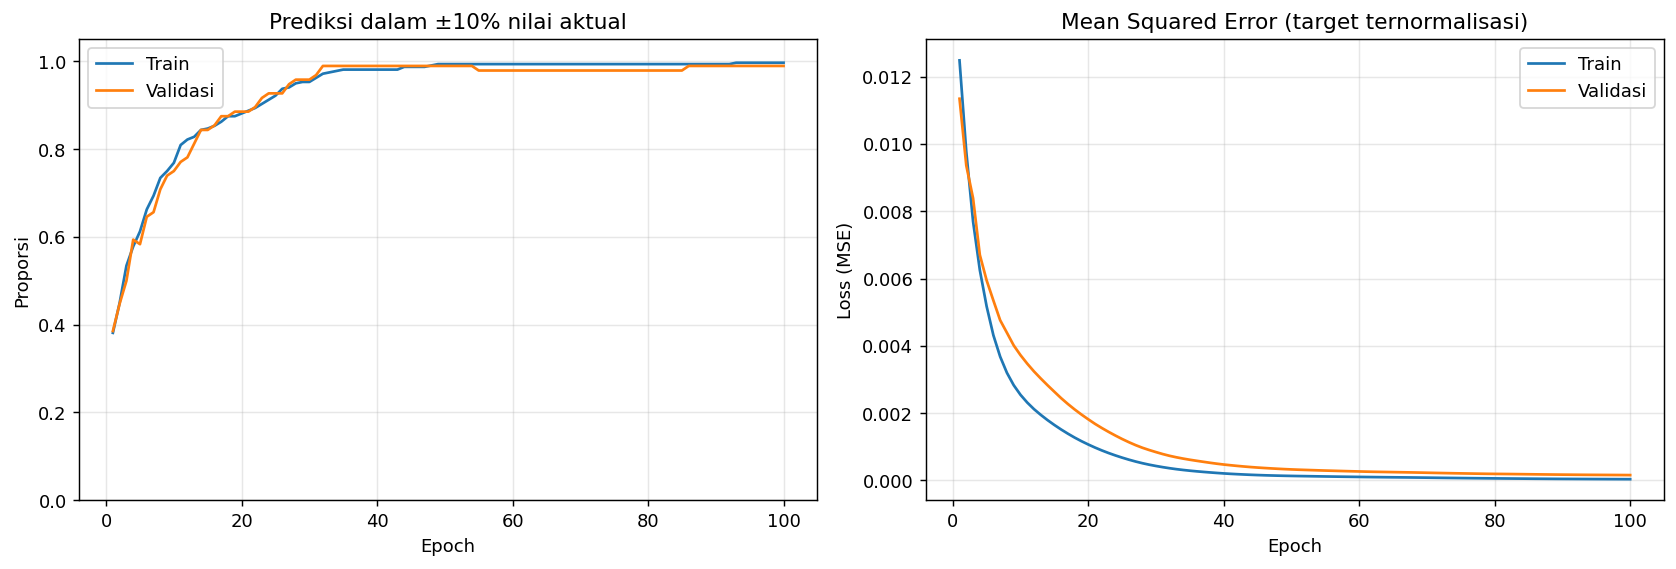

In [ ]:
epochs = np.arange(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, history.history["within_10pct"], label="Train")
axes[0].plot(epochs, history.history["val_within_10pct"], label="Validasi")
axes[0].set(title="Prediksi dalam ±10% nilai aktual", xlabel="Epoch", ylabel="Proporsi")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="Train")
axes[1].plot(epochs, history.history["val_loss"], label="Validasi")
axes[1].set(title="Mean Squared Error (target ternormalisasi)", xlabel="Epoch", ylabel="Loss (MSE)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation and limitations

The saved test output reports MAE **316.87**, RMSE **458.09**, R² **0.9983**, and **99%** of predictions within ±10% of the actual amount. MAE and RMSE use the original target units; the currency is not established here.

The test partition contains 100 of the 500 records. The remaining 400 records are scaled, then Keras reserves 20% for validation (320 optimization / 80 validation records). Thus the test set is excluded from scaler fitting, but the validation records influence scaler parameters. A future experiment should separate train, validation, and test before fitting scalers; its results must be reported separately.

This is one saved educational experiment. No baseline model, repeated-seed evaluation, or external validation is included. The original CSV source/license and data realism have not been verified. Strong results on this split do not establish real-world performance.
